# Poisson Goal Model

This notebook builds a Poisson model to predict match outcomes from expected goals. Rather than predicting win/draw/loss directly, it models how many goals each team is expected to score, then converts those goal rates into outcome probabilities. Team strength is carried by the Elo differential merged in during preprocessing, which is steadier than estimating a separate rating per national team given how few matches each one plays.

## Imports

In [1]:
from pathlib import Path
from scipy.stats import poisson
import statsmodels.formula.api as smf
import statsmodels.api as sm
import numpy as np
import pandas as pd

## Load the data

The model uses `matches_preprocessed_readable.csv` rather than the modeling base file, because a goals model needs the actual home and away scores (the modeling base drops them to avoid leakage in the classification task). Rows without both scores are removed since they can't be used, and scores are cast to integers.

In [2]:
def load_matches(processed_dir="../data/processed"):
    """Load the readable EDA dataset and keep rows usable for a goals model."""
    path = Path(processed_dir) / "matches_preprocessed_readable.csv"
    df = pd.read_csv(path, parse_dates=["date"])

    # A goals model needs both scores
    df = df.dropna(subset=["home_score", "away_score"]).copy()
    df["home_score"] = df["home_score"].astype(int)
    df["away_score"] = df["away_score"].astype(int)
    return df

## Fit the model

Two separate Poisson regressions are fit: one for home goals and one for away goals, both driven by the Elo differential (`home_elo - away_elo`) and a neutral-site indicator. The home model uses the differential directly, while the away model uses its negation, since a positive edge for the home team is a negative edge for the away team.

In [3]:
def fit_poisson(train_df):
    """Fit two Poisson GLMs (home goals, away goals) driven by the Elo differential."""
    df = train_df.copy()
    df["elo_diff"] = df["home_elo"] - df["away_elo"]
    df["neg_elo_diff"] = -df["elo_diff"]
    df["neutral_int"] = df["neutral"].astype(int)

    # Positive elo_diff should raise expected home goals
    home_model = smf.glm(
        "home_score ~ elo_diff + neutral_int", data=df, family=sm.families.Poisson()
    ).fit()

    # The away team's edge is the negated differential
    away_model = smf.glm(
        "away_score ~ neg_elo_diff + neutral_int", data=df, family=sm.families.Poisson()
    ).fit()

    return home_model, away_model

## Predict a match

For a given fixture, each fitted model produces an expected goal count. Assuming the two scores are independent, the outer product of their Poisson distributions gives a full score matrix of P(home = i, away = j). Summing the lower triangle, diagonal, and upper triangle of that matrix collapses it into home win, draw, and away win probabilities.

In [4]:
def predict_match(home_model, away_model, home_elo, away_elo, neutral=False, max_goals=10):
    """Return expected goals and W/D/L probabilities for one fixture."""
    elo_diff = home_elo - away_elo
    neutral_int = int(neutral)

    # Expected goals for each side
    lam_home = home_model.predict(
        pd.DataFrame({"elo_diff": [elo_diff], "neutral_int": [neutral_int]})
    ).iloc[0]
    lam_away = away_model.predict(
        pd.DataFrame({"neg_elo_diff": [-elo_diff], "neutral_int": [neutral_int]})
    ).iloc[0]

    # Build the score matrix P(home=i, away=j), assuming independence
    home_probs = poisson.pmf(np.arange(max_goals + 1), lam_home)
    away_probs = poisson.pmf(np.arange(max_goals + 1), lam_away)
    matrix = np.outer(home_probs, away_probs)

    # Collapse the matrix into the three outcomes
    result = {
        "lambda_home": lam_home,
        "lambda_away": lam_away,
        "home_win": np.tril(matrix, -1).sum(),   # home goals > away goals
        "draw": np.trace(matrix),                # equal goals
        "away_win": np.triu(matrix, 1).sum(),    # away goals > home goals
    }
    return result

def predict_from_diff(home_model, away_model, elo_diff, neutral=False, max_goals=10):
    """predict_match variant taking the Elo differential directly."""
    return predict_match(home_model, away_model,
                         home_elo=elo_diff, away_elo=0,
                         neutral=neutral, max_goals=max_goals)

## Split and fit

The data is split to match the classifier pipeline exactly: training on 1994-2021, validating on 2022-2025, and testing on the shared 102-match 2026 World Cup set. Rows missing either Elo rating are dropped first. The printed counts verify alignment with the shared processed files, and the training rows are also used to recover the exact standardization constants needed to convert the shared test file's scaled Elo differential back to raw units.

In [5]:
# Load the goals-bearing data 
df = load_matches("../data/processed")
df_model = df.dropna(subset=["home_elo", "away_elo"]).copy()

# Same partition rule as the classifier pipeline: train = 1994-2021, val = 2022-2025, test = the 102 WC matches.
train_df = df_model[df_model["year"] < 2022].copy()
val_df   = df_model[(df_model["year"] >= 2022) & (df_model["year"] < 2026)].copy()

# Verify alignment with the shared files 
print("Train:", train_df.shape[0], "(expect 23192)")
print("Val:  ", val_df.shape[0],   "(expect 4106)")

# Fit on the training split.
home_model, away_model = fit_poisson(train_df)

# Recover the exact scaler constants from the SAME train rows the classifiers scaled on then de-standardize the shared 2026 test file.
diff = (train_df["home_elo"] - train_df["away_elo"])
ELO_MU, ELO_SIGMA = diff.mean(), diff.std(ddof=0)   # ddof=0 matches sklearn StandardScaler
print(f"Scaler: mean={ELO_MU}, std={ELO_SIGMA}")

test_df = pd.read_csv("../data/processed/poisson_2026_test_data.csv")
test_df["elo_diff_raw"] = test_df["elo_diff_standardized"] * ELO_SIGMA + ELO_MU
print("Test: ", test_df.shape[0], "(expect 102)")

Train: 23192 (expect 23192)
Val:   4106 (expect 4106)
Scaler: mean=19.27061055536392, std=275.0420681586579
Test:  102 (expect 102)


## Evaluation

The model is scored on all three temporal splits using two metrics. Accuracy measures how often the highest-probability outcome (home win, draw, or away win) matches the actual result. Because a draw rarely has the single highest probability in a Poisson score matrix, the model predicts draws infrequently and accuracy alone understates its quality, so log-loss is reported alongside it to measure how well-calibrated the full probability estimates are.

In [6]:
from sklearn.metrics import accuracy_score, log_loss

def true_result(row):
    """Actual W/D/L label from the real scoreline."""
    if row["home_score"] > row["away_score"]:
        return "home_win"
    elif row["home_score"] < row["away_score"]:
        return "away_win"
    return "draw"

def evaluate(home_model, away_model, data, max_goals=10):
    """Return accuracy and log-loss of the derived W/D/L predictions on `data`."""
    classes = ["away_win", "draw", "home_win"]   # lexicographic order for log_loss
    probs, preds, truths = [], [], []

    for _, row in data.iterrows():
        r = predict_match(
            home_model, away_model,
            home_elo=row["home_elo"], away_elo=row["away_elo"],
            neutral=bool(row["neutral"]), max_goals=max_goals,
        )
        p = np.array([r["away_win"], r["draw"], r["home_win"]])
        p = p / p.sum()                          # renormalize so it sums to 1
        probs.append(p)
        preds.append(classes[int(np.argmax(p))])
        truths.append(true_result(row))

    acc = accuracy_score(truths, preds)
    ll = log_loss(truths, probs, labels=classes)
    return acc, ll

In [7]:
def evaluate_2026(home_model, away_model, data, max_goals=10):
    """Score the model on the shared 2026 test file (elo_diff_raw + neutral + labels)."""
    classes = ["away_win", "draw", "home_win"]
    probs, preds = [], []
    for _, row in data.iterrows():
        r = predict_from_diff(home_model, away_model,
                              elo_diff=row["elo_diff_raw"],
                              neutral=bool(row["neutral"]), max_goals=max_goals)
        p = np.array([r["away_win"], r["draw"], r["home_win"]])
        p = p / p.sum()
        probs.append(p)
        preds.append(classes[int(np.argmax(p))])
    acc = accuracy_score(data["match_result"], preds)
    ll = log_loss(data["match_result"], probs, labels=classes)
    return acc, ll

train_acc, train_ll = evaluate(home_model, away_model, train_df)
val_acc,   val_ll   = evaluate(home_model, away_model, val_df)
test_acc,  test_ll  = evaluate_2026(home_model, away_model, test_df)

print(f"Train accuracy: {train_acc} | log-loss: {train_ll}")
print(f"Val accuracy:   {val_acc} | log-loss: {val_ll}")
print(f"Test accuracy:  {test_acc} | log-loss: {test_ll}  (2026 World Cup, n=102)")

Train accuracy: 0.5809761986892031 | log-loss: 0.8990977732975106
Val accuracy:   0.5949829517778861 | log-loss: 0.8749160214357278
Test accuracy:  0.6666666666666666 | log-loss: 0.8609817380754806  (2026 World Cup, n=102)


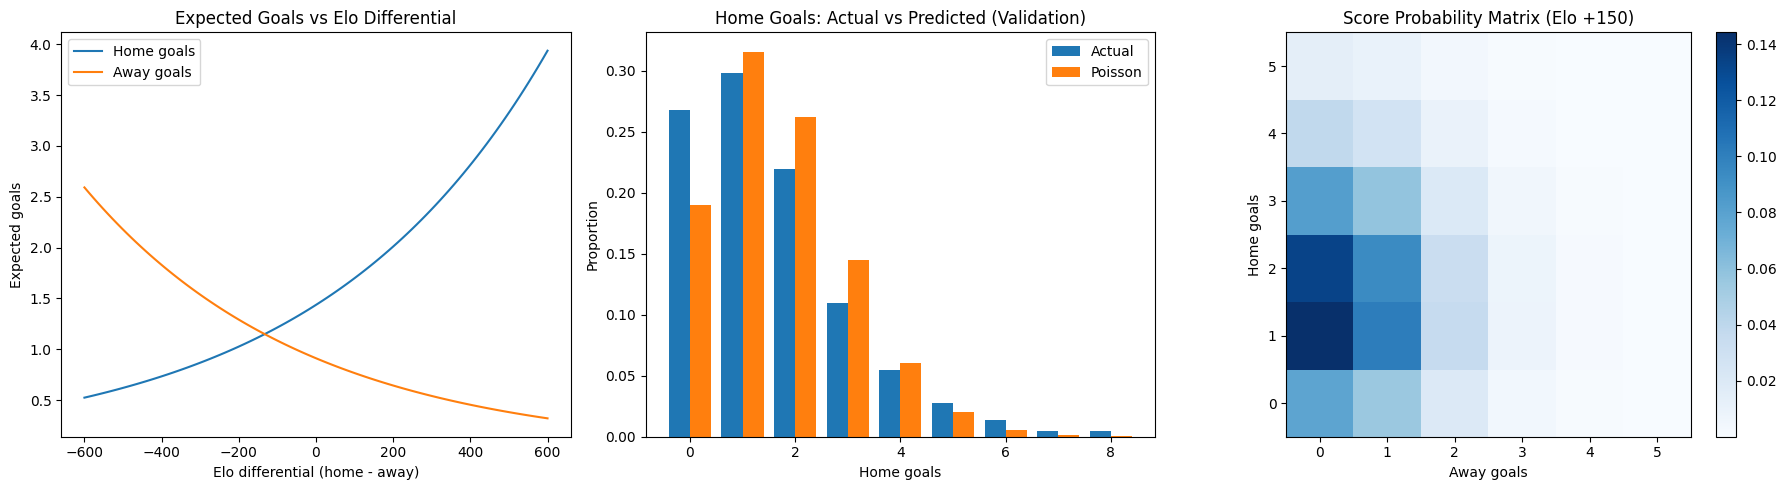

In [8]:
import matplotlib.pyplot as plt

def plot_diagnostics(home_model, away_model, data):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Plot 1: predicted expected goals vs Elo differential
    diffs = np.linspace(-600, 600, 100)
    lam_home = home_model.predict(
        pd.DataFrame({"elo_diff": diffs, "neutral_int": np.zeros_like(diffs)})
    )
    lam_away = away_model.predict(
        pd.DataFrame({"neg_elo_diff": -diffs, "neutral_int": np.zeros_like(diffs)})
    )
    axes[0].plot(diffs, lam_home, label="Home goals")
    axes[0].plot(diffs, lam_away, label="Away goals")
    axes[0].set_xlabel("Elo differential (home - away)")
    axes[0].set_ylabel("Expected goals")
    axes[0].set_title("Expected Goals vs Elo Differential")
    axes[0].legend()

    # Plot 2: predicted vs actual goal distribution 
    max_g = 8
    actual = data["home_score"].clip(upper=max_g).value_counts(normalize=True).sort_index()
    mean_lambda = home_model.predict(
        data.assign(
            elo_diff=data["home_elo"] - data["away_elo"],
            neutral_int=data["neutral"].astype(int),
        )[["elo_diff", "neutral_int"]]
    ).mean()
    predicted = poisson.pmf(np.arange(max_g + 1), mean_lambda)
    axes[1].bar(actual.index - 0.2, actual.values, width=0.4, label="Actual")
    axes[1].bar(np.arange(max_g + 1) + 0.2, predicted, width=0.4, label="Poisson")
    axes[1].set_xlabel("Home goals")
    axes[1].set_ylabel("Proportion")
    axes[1].set_title("Home Goals: Actual vs Predicted (Validation)")
    axes[1].legend()

    # Plot 3: example score matrix heatmap
    r_home = home_model.predict(pd.DataFrame({"elo_diff": [150], "neutral_int": [0]})).iloc[0]
    r_away = away_model.predict(pd.DataFrame({"neg_elo_diff": [-150], "neutral_int": [0]})).iloc[0]
    hp = poisson.pmf(np.arange(6), r_home)
    ap = poisson.pmf(np.arange(6), r_away)
    matrix = np.outer(hp, ap)
    im = axes[2].imshow(matrix, origin="lower", cmap="Blues")
    axes[2].set_xlabel("Away goals")
    axes[2].set_ylabel("Home goals")
    axes[2].set_title("Score Probability Matrix (Elo +150)")
    fig.colorbar(im, ax=axes[2], fraction=0.046)

    plt.tight_layout()
    plt.show()

plot_diagnostics(home_model, away_model, val_df)

## Results

The model reaches 0.581 train and 0.595 validation accuracy, and 0.667 accuracy with 0.861 log-loss on the shared 102-match 2026 World Cup test set. Test performance exceeding train and validation partly reflects the small test set (each match is ~1% of accuracy) and the World Cup's larger share of lopsided Elo gaps, where the model is most reliable. Log-loss improves from validation (0.8749) to test (0.861) and sits well below the three-class random baseline of 1.10, confirming the Elo-driven goal rates carry real, well-calibrated signal. Accuracy remains capped by draw prediction: a draw seldom holds the single highest probability in a Poisson score matrix, so the model rarely outputs it as the argmax even when its draw probability is substantial.